In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [2]:
from datasets import load_dataset

dataset = load_dataset("ylecun/mnist")

/Users/vallurileelasaikrishna/mnist/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

In [4]:
X_train = np.array(dataset["train"]["image"]).reshape(-1, 784) / 255
y_train = list(dataset["train"]["label"])
X_test = np.array(dataset["test"]["image"]).reshape(-1, 784) / 255
y_test = list(dataset["test"]["label"])

4

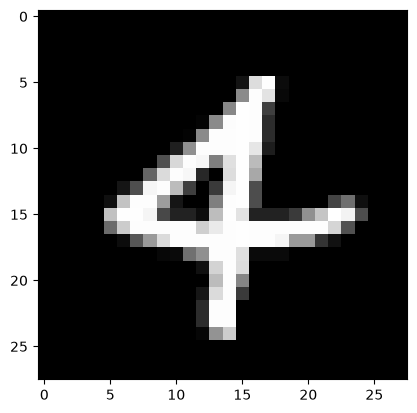

In [20]:
plt.imshow(X_train[150].reshape(28,28), cmap="grey")
y_train[150]

In [6]:
X_train[3454]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [7]:
X_train.shape

(60000, 784)

### Parameters

- one input layer:  
    input = X(= A0)(784,60000)  

- first hidden layers:  
    W1(100,784)  
    b1(100,1)  
    Z1(100,60000) = W1*A0 + b1  
    A1 = Relu(Z1)  

- second hidden layer:  
    W2(100,100)  
    b2(100,1)  
    Z2(100,60000) = W2*A1 + b2  
    A2 = Relu(Z2)  

- final output layer:    
    W3(10,100)  
    b3(10,1)  
    Z3(10,60000) = W3*A2 + b3  
    A3 = softmax(Z3)  
    output = A3  

In [8]:
def Relu(z):
    return np.maximum(0, z)

In [9]:
def softmax(z):
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)

In [38]:
def init_para(X_train):
    A0 = X_train.T

    np.random.seed(67)
    W1 = np.random.randn(100, 784)* np.sqrt(2 / 784)
    b1 = np.random.randn(100, 1)

    W2 = np.random.randn(100, 100)* np.sqrt(2 / 100)
    b2 = np.random.randn(100, 1)

    W3 = np.random.randn(10, 100)* np.sqrt(2 / 100)
    b3 = np.random.randn(10, 1)

    return A0, W1, b1, W2, b2, W3, b3

In [39]:
def forward_prop(A0, W1, b1, W2, b2, W3, b3):
    Z1 = W1 @ A0 + b1
    A1 = Relu(Z1)

    Z2 = W2 @ A1 + b2
    A2 = Relu(Z2)

    Z3 = W3 @ A2 + b3
    A3 = softmax(Z3)

    return Z1, A1, Z2, A2, Z3, A3

In [40]:
def deriv_Relu(z):
    return (z>0).astype(float)

In [ ]:
def loss_function(y, y_pred):
    return -np.sum(y * (np.log(y_pred))) 

In [42]:
def one_hot(y):
    y = np.array(y)
    m = y.size  
    one_hot_y = np.zeros((10, m))
    one_hot_y[y, np.arange(m)] = 1
    
    return one_hot_y

In [ ]:
def back_prop(A0, Z1, A1, W2, Z2, A2, W3, A3, y_train):
    m = A0.shape[1]
    y = one_hot(y_train)

    dZ3 = A3 - y
    dW3 = dZ3 @ A2.T / m
    db3 = np.sum(dZ3, axis=1, keepdims=True) / m

    dZ2 = W3.T @ dZ3 * deriv_Relu(Z2)
    dW2 = dZ2 @ A1.T / m
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m

    dZ1 = W2.T @ dZ2 * deriv_Relu(Z1)
    dW1 = dZ1 @ A0.T / m 
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m
    
    return dW1, db1, dW2, db2, dW3, db3

In [44]:
def update_para(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, alpha):
    W1 -= alpha * dW1
    W2 -= alpha * dW2
    W3 -= alpha * dW3
    b1 -= alpha * db1
    b2 -= alpha * db2
    b3 -= alpha * db3

    return W1, W2, W3, b1, b2, b3

In [45]:
def gradient_descent(X_train, y_train, iterations, tol, alpha, init = False, para = []):
    if not init:
        A0, W1, b1, W2, b2, W3, b3 = init_para(X_train)
    else:
        A0, W1, b1, W2, b2, W3, b3 = para
    for j in range(iterations + 1):
        Z1, A1, Z2, A2, Z3, A3 = forward_prop(A0, W1, b1, W2, b2, W3, b3)
        dW1, db1, dW2, db2, dW3, db3 = back_prop(A0, Z1, A1, W2, Z2, A2, W3, A3, y_train)
        W1, W2, W3, b1, b2, b3 = update_para(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, alpha)
        if not (j % 100):
            print("iteration :", j)
            print("accuracy :", np.mean(np.argmax(A3, axis=0) == np.array(y_train).flatten()) * 100)
    return W1, b1, W2, b2, W3, b3

In [46]:
W1, b1, W2, b2, W3, b3 = gradient_descent(X_train, y_train, 5000, 0, 0.01)

iteration : 0
accuracy : 9.751666666666667
iteration : 100
accuracy : 66.47166666666666
iteration : 200
accuracy : 77.36
iteration : 300
accuracy : 82.00166666666667
iteration : 400
accuracy : 84.52499999999999
iteration : 500
accuracy : 86.08333333333333
iteration : 600
accuracy : 87.06333333333333
iteration : 700
accuracy : 87.74333333333333
iteration : 800
accuracy : 88.3
iteration : 900
accuracy : 88.755
iteration : 1000
accuracy : 89.08
iteration : 1100
accuracy : 89.37166666666667
iteration : 1200
accuracy : 89.62
iteration : 1300
accuracy : 89.81666666666666
iteration : 1400
accuracy : 90.03
iteration : 1500
accuracy : 90.18833333333333
iteration : 1600
accuracy : 90.38166666666667
iteration : 1700
accuracy : 90.53999999999999
iteration : 1800
accuracy : 90.67833333333334
iteration : 1900
accuracy : 90.82333333333334
iteration : 2000
accuracy : 90.97666666666666
iteration : 2100
accuracy : 91.07499999999999
iteration : 2200
accuracy : 91.20166666666667
iteration : 2300
accuracy 

In [52]:
nW1, nb1, nW2, nb2, nW3, nb3 = gradient_descent(X_train, y_train, 5000, 0, 0.1, True, [X_train.T, W1, b1, W2, b2, W3, b3])

iteration : 0
accuracy : 93.38
iteration : 100
accuracy : 93.88166666666666
iteration : 200
accuracy : 94.315
iteration : 300
accuracy : 94.74166666666667
iteration : 400
accuracy : 95.02000000000001
iteration : 500
accuracy : 95.29666666666667
iteration : 600
accuracy : 95.55166666666666
iteration : 700
accuracy : 95.785
iteration : 800
accuracy : 95.97
iteration : 900
accuracy : 96.16333333333333
iteration : 1000
accuracy : 96.325
iteration : 1100
accuracy : 96.5
iteration : 1200
accuracy : 96.64166666666667
iteration : 1300
accuracy : 96.77333333333334
iteration : 1400
accuracy : 96.91666666666666
iteration : 1500
accuracy : 97.02333333333333
iteration : 1600
accuracy : 97.12666666666667
iteration : 1700
accuracy : 97.24833333333333
iteration : 1800
accuracy : 97.34166666666667
iteration : 1900
accuracy : 97.44666666666667
iteration : 2000
accuracy : 97.545
iteration : 2100
accuracy : 97.615
iteration : 2200
accuracy : 97.705
iteration : 2300
accuracy : 97.76166666666667
iteration :

### Saving

In [ ]:
params = {
    "W1": nW1,
    "b1": nb1,
    "W2": nW2,
    "b2": nb2,
    "W3": nW3,
    "b3": nb3,
}

np.savez("../weights_nn.npz", **params)

### Test


In [ ]:
params = np.load("../weights_nn.npz")

W1 = params["W1"]
W2 = params["W2"]
W3 = params["W3"]
b1 = params["b1"]
b2 = params["b2"]
b3 = params["b3"]

In [55]:
Z1, A1, Z2, A2, Z3, A3 = forward_prop(X_test.T, W1, b1, W2, b2, W3, b3)

In [56]:
print("accuracy :", np.mean(np.argmax(A3, axis=0) == np.array(y_test).flatten()) * 100)

accuracy : 97.44
